In [ ]:
import os

os.makedirs("data", exist_ok=True)
os.makedirs("docs", exist_ok=True)
os.makedirs("notebooks", exist_ok=True)

print("Folders created")

Folders created


In [ ]:
!git clone https://github.com/UniversalDependencies/UD_Ukrainian-ParlaMint.git

Cloning into 'UD_Ukrainian-ParlaMint'...
remote: Enumerating objects: 142, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 142 (delta 7), reused 4 (delta 3), pack-reused 129 (from 1)
Receiving objects: 100% (142/142), 6.22 MiB | 22.49 MiB/s, done.
Resolving deltas: 100% (81/81), done.


In [ ]:
import csv

INPUT_FILES = [
    "UD_Ukrainian-ParlaMint/uk_parlamint-ud-train.conllu",
    "UD_Ukrainian-ParlaMint/uk_parlamint-ud-dev.conllu",
    "UD_Ukrainian-ParlaMint/uk_parlamint-ud-test.conllu"
]

OUTPUT_FILE = "data/raw.csv"


def extract_sentences(conllu_file):
    sentences = []
    current_tokens = []

    with open(conllu_file, "r", encoding="utf-8") as f:
        for line in f:

            line = line.strip()

            if line == "":
                if current_tokens:
                    sentence = " ".join(current_tokens)
                    sentences.append(sentence)
                    current_tokens = []
                continue

            if line.startswith("#"):
                continue

            parts = line.split("\t")

            if len(parts) > 1:
                token = parts[1]
                current_tokens.append(token)

    return sentences


all_sentences = []

for file in INPUT_FILES:
    sentences = extract_sentences(file)
    all_sentences.extend(sentences)

print("Total sentences found:", len(all_sentences))

# беремо тільки 2000 для Lab 1
all_sentences = all_sentences[:2000]

with open(OUTPUT_FILE, "w", encoding="utf-8", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["id", "text"])

    for i, text in enumerate(all_sentences):
        writer.writerow([i, text])

print("Saved to data/raw.csv")

Total sentences found: 7142
Saved to data/raw.csv


In [ ]:
import pandas as pd

df = pd.read_csv("data/raw.csv")

print("Number of texts:", len(df))
df.head(10)


Number of texts: 2000


,id,text
0,0,"Доброго ранку , шановні народні депутати , зап..."
1,1,"Прошу , шановні колеги , підготуватися до реєс..."
2,2,"Ввімкніть систему "" Рада "" ."
3,3,Зареєструвалося - 433
4,4,Зареєстровано 433 народних депутати .
5,5,Ранкове засідання оголошую відкритим .
6,6,"Шановні колеги , сьогодні велике свято Покров ..."
7,7,"Я щиро вітаю вас з цим святом і сподіваюся , щ..."
8,8,"Шановні народні депутати , сьогодні день народ..."
9,9,"Давайте привітаємо його , побажаємо міцного зд..."


In [ ]:
import re

def clean_text(text):

    text = str(text)

    text = text.replace("’", "'")

    text = re.sub(r"\s+", " ", text)

    text = re.sub(r"http\S+", "<URL>", text)

    text = text.strip()

    return text


df["text"] = df["text"].apply(clean_text)

df.to_csv("data/processed.csv", index=False)

print("Saved to data/processed.csv")

Saved to data/processed.csv


In [ ]:
# довжина в символах
df["char_len"] = df["text"].apply(len)

# довжина в словах
df["word_len"] = df["text"].apply(lambda x: len(x.split()))

print("Mean char length:", df["char_len"].mean())
print("Median char length:", df["char_len"].median())

print("Mean word length:", df["word_len"].mean())
print("Median word length:", df["word_len"].median())


Mean char length: 93.66
Median char length: 68.0
Mean word length: 15.7685
Median word length: 12.0


In [ ]:
# Перевірка точних дублів

# кількість дублів
duplicates = df.duplicated(subset=["text"]).sum()

# відсоток дублів
duplicate_percent = duplicates / len(df) * 100

print(f"Total texts: {len(df)}")
print(f"Duplicate texts: {duplicates}")
print(f"Duplicate percent: {duplicate_percent:.2f}%")

Total texts: 2000
Duplicate texts: 235
Duplicate percent: 11.75%


In [ ]:
# показати приклади дублів
duplicate_rows = df[df.duplicated(subset=["text"], keep=False)]

print("Example duplicates:")
duplicate_rows.head(10)


Example duplicates:


,id,text,char_len,word_len
12,12,Шановні колеги !,16,3
16,16,Перше .,7,2
19,19,І друге питання .,17,4
22,22,Нема заперечень ?,17,3
27,27,Прошу голосувати .,18,3
29,29,Рішення прийнято .,18,3
44,44,Прошу голосувати .,18,3
46,46,Рішення прийнято .,18,3
47,47,Дякую .,7,2
54,54,Прошу голосувати .,18,3


In [ ]:
short_texts = df[df["word_len"] < 5]

print(f"Short texts (<5 words): {len(short_texts)}")
print(f"Short texts percent: {len(short_texts)/len(df)*100:.2f}%")

Short texts (<5 words): 408
Short texts percent: 20.40%


In [ ]:
import re

def is_garbage(text):
    return bool(re.fullmatch(r"[\d\W_]+", text))

garbage = df[df["text"].apply(is_garbage)]

print(f"Garbage texts: {len(garbage)}")
print(f"Garbage percent: {len(garbage)/len(df)*100:.2f}%")

Garbage texts: 1
Garbage percent: 0.05%


In [ ]:
def clean_text(text):
    text = str(text)

    # прибираємо зайві пробіли
    text = re.sub(r"\s+", " ", text)

    # прибираємо пробіли перед пунктуацією
    text = re.sub(r"\s([?.!,])", r"\1", text)

    return text.strip()


df["text"] = df["text"].apply(clean_text)
df["word_len"] = df["text"].apply(lambda x: len(x.split()))

df = df[df["word_len"] >= 5]

print("After removing short texts:", len(df))
before = len(df)

df = df.drop_duplicates(subset=["text"])

after = len(df)

print("Removed duplicates:", before - after)
print("Final size:", after)

After removing short texts: 1445
Removed duplicates: 8
Final size: 1437


In [ ]:
df = df.reset_index(drop=True)
df["id"] = df.index

df[["id", "text"]].to_csv("data/processed.csv", index=False)

print("processed.csv recreated successfully")


processed.csv recreated successfully


In [ ]:
import pandas as pd
from collections import Counter
import re

# Завантажуємо очищений датасет
df = pd.read_csv("data/processed.csv")

# Збираємо всі тексти
all_text = " ".join(df['text'].astype(str))

# Розбиваємо на слова, залишаємо лише літери та апостроф
words = re.findall(r'\b[а-яіїєґА-ЯІЇЄҐ\']{5,}\b', all_text)

# Рахуємо частоту
counter = Counter(words)

# Топ 50 найчастіше вживаних слів довше 5 літер
top_words = counter.most_common(50)

for word, freq in top_words:
    print(word, freq)



України 241
питання 156
колеги 130
сьогодні 119
Шановні 108
Верховної 95
цього 84
зараз 83
рішення 82
ласка 60
Україні 50
комісії 49
маємо 47
прошу 46
проект 45
шановні 41
повинні 40
треба 39
фракція 39
постанови 38
питань 37
голосування 37
проекту 36
закон 35
тільки 34
депутатів 33
Криму 33
порядку 32
прийняти 32
партії 32
фракцій 31
людей 30
депутати 29
Прошу 29
зв'язку 29
давайте 29
нашої 29
постанову 29
парламенту 29
разом 29
людини 29
Закону 28
країни 28
народу 28
будемо 27
підготовки 27
спорту 27
закону 27
також 26
Президента 26


In [ ]:
import pandas as pd

# Відкриваємо raw.csv
df_raw = pd.read_csv("raw.csv")
df_raw.head()  # подивимося перші 5 рядків

FileNotFoundError: [Errno 2] No such file or directory: 'raw.csv'

In [ ]:
# Групуємо токени по sent_id
sentences_df = df.groupby("sent_id")["token"].apply(lambda x: " ".join(x)).reset_index()
sentences_df.rename(columns={"token": "raw_text"}, inplace=True)
sentences_df.head(5)

In [ ]:
# =============================
# 0. Встановлюємо бібліотеки
# =============================
!pip install pandas

# =============================
# 1. Імпорти
# =============================
import os
import pathlib
import shutil
import pandas as pd
import json
import sys

# =============================
# 2. Створюємо структуру репозиторію
# =============================
folders = [
    "data/raw",
    "data/processed_v2",
    "data/sample",
    "docs",
    "src",
    "tests",
    "notebooks",
    "labs/lab02"
]

for f in folders:
    pathlib.Path(f).mkdir(parents=True, exist_ok=True)

# =============================
# 3. Завантажте ваш raw.csv у Colab
#    і вкажіть правильний шлях нижче
# =============================
from google.colab import files

uploaded = files.upload()  # з’явиться кнопка вибору файлу
# Припустимо, ви завантажили raw.csv у Files Colab
shutil.copy("/content/raw.csv", "data/raw/raw.csv")


In [ ]:
preprocess_code = """
import re

URL_RE = re.compile(r'https?://\\S+|www\\.\\S+')
EMAIL_RE = re.compile(r'\\S+@\\S+')
PHONE_RE = re.compile(r'\\+?\\d[\\d\\s\\-()]{7,}')
MULTISPACE_RE = re.compile(r'\\s+')

def clean_text(text: str) -> str:
    text = str(text).replace("\\xa0", " ")
    text = MULTISPACE_RE.sub(" ", text)
    return text.strip()

def normalize_text(text: str) -> str:
    text = text.replace("’","'").replace("ʼ","'")
    text = text.replace("—","-")
    text = text.replace("“",'"').replace("”",'"')
    return text

def mask_pii(text: str) -> str:
    text = URL_RE.sub("<URL>", text)
    text = EMAIL_RE.sub("<EMAIL>", text)
    text = PHONE_RE.sub("<PHONE>", text)
    return text

def preprocess(text: str) -> str:
    text = clean_text(text)
    text = normalize_text(text)
    text = mask_pii(text)
    return text
"""

with open("src/preprocess.py", "w", encoding="utf-8") as f:
    f.write(preprocess_code)

In [ ]:
sys.path.append("src")
from preprocess import preprocess

df = pd.read_csv("data/raw/raw.csv")  # Ваш UD CSV
# Групуємо токени по sent_id в речення
sentences_df = df.groupby("sent_id")["token"].apply(lambda x: " ".join(x)).reset_index()
sentences_df.rename(columns={"token": "raw_text"}, inplace=True)
sentences_df.head(5)

In [ ]:
sentences_df["clean_text"] = sentences_df["raw_text"].apply(preprocess)
sentences_df.head(5)

In [ ]:
# Зберігаємо тільки очищені речення
sentences_df.to_csv("data/processed_v2/dataset_clean.csv", index=False)

# Малий sample для перевірки
sample_size = min(50, len(sentences_df))
sentences_df.sample(sample_size).to_csv("data/sample/sample.csv", index=False)

In [ ]:
import pandas as pd
import os
import json
from datetime import datetime
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
from google.colab import files
import pandas as pd

# завантаження локального файлу processed_v2.csv
uploaded = files.upload()
filename = list(uploaded.keys())[0]
print(f"Uploaded file: {filename}")

# читаємо CSV
df = pd.read_csv(filename)

print("Shape:", df.shape)
print(df["split"].value_counts())

Saving processed_v2.csv to processed_v2.csv
Uploaded file: processed_v2.csv
Shape: (109166, 8)
split
train    87369
test     10955
dev      10842
Name: count, dtype: int64


In [ ]:
print("Колонки:")
print(df.columns)

print("\nРозподіл split:")
print(df["split"].value_counts())

Колонки:
Index(['split', 'sent_id', 'token_id', 'token', 'lemma', 'upos', 'head',
       'deprel'],
      dtype='object')

Розподіл split:
split
train    87369
test     10955
dev      10842
Name: count, dtype: int64


In [ ]:
os.makedirs("data/splits", exist_ok=True)
os.makedirs("data/sample", exist_ok=True)
os.makedirs("docs", exist_ok=True)
os.makedirs("src", exist_ok=True)

In [ ]:
train_df = df[df["split"]=="train"]
val_df   = df[df["split"]=="dev"]
test_df  = df[df["split"]=="test"]

train_df.to_csv("train.csv",index=False)
val_df.to_csv("validation.csv",index=False)
test_df.to_csv("test.csv",index=False)

print("CSV split файли створено")

CSV split файли створено


In [ ]:
!pip install scikit-learn pandas matplotlib

In [ ]:
import pandas as pd

train_df = pd.read_csv("train.csv")
val_df   = pd.read_csv("validation.csv")
test_df  = pd.read_csv("test.csv")

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

print(train_df.columns)
train_df.head()

Train: 87369
Val: 10842
Test: 10955
Index(['split', 'sent_id', 'token_id', 'token', 'lemma', 'upos', 'head',
       'deprel'],
      dtype='object')


,split,sent_id,token_id,token,lemma,upos,head,deprel
0,train,ParlaMint-UA_2003-10-14-m0.u1.p1.lang1.s1,1,Доброго,добрий,ADJ,2,amod
1,train,ParlaMint-UA_2003-10-14-m0.u1.p1.lang1.s1,2,ранку,ранок,NOUN,0,root
2,train,ParlaMint-UA_2003-10-14-m0.u1.p1.lang1.s1,3,",",",",PUNCT,6,punct
3,train,ParlaMint-UA_2003-10-14-m0.u1.p1.lang1.s1,4,шановні,шановний,ADJ,6,amod
4,train,ParlaMint-UA_2003-10-14-m0.u1.p1.lang1.s1,5,народні,народний,ADJ,6,amod


In [ ]:
# базовий текст (тільки токен)
train_df["text"] = train_df["token"].astype(str)
val_df["text"]   = val_df["token"].astype(str)
test_df["text"]  = test_df["token"].astype(str)

# покращений текст (token + lemma)
train_df["text2"] = train_df["token"] + " " + train_df["lemma"]
val_df["text2"]   = val_df["token"] + " " + val_df["lemma"]
test_df["text2"]  = test_df["token"] + " " + test_df["lemma"]

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

pipe1 = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1,1))),
    ("clf", LogisticRegression(max_iter=300))
])

pipe1.fit(train_df["text"], train_df["upos"])

Pipeline(steps=[('tfidf', TfidfVectorizer()),
                ('clf', LogisticRegression(max_iter=300))])

In [ ]:
pipe2 = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1,2), sublinear_tf=True)),
    ("clf", LogisticRegression(max_iter=500))
])

pipe2.fit(train_df["text2"], train_df["upos"])

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True)),
                ('clf', LogisticRegression(max_iter=500))])

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

# baseline 1
pred1 = pipe1.predict(test_df["text"])

print("=== BASELINE 1 ===")
print("Accuracy:", accuracy_score(test_df["upos"], pred1))
print("Macro-F1:", f1_score(test_df["upos"], pred1, average="macro"))

# baseline 2
pred2 = pipe2.predict(test_df["text2"])

print("\n=== BASELINE 2 ===")
print("Accuracy:", accuracy_score(test_df["upos"], pred2))
print("Macro-F1:", f1_score(test_df["upos"], pred2, average="macro"))

print("\nClassification report:")
print(classification_report(test_df["upos"], pred2))

=== BASELINE 1 ===
Accuracy: 0.7707895937927887
Macro-F1: 0.6631182169365623

=== BASELINE 2 ===
Accuracy: 0.8216339570972159
Macro-F1: 0.694705275522238

Classification report:
              precision    recall  f1-score   support

         ADJ       0.99      0.72      0.83      1043
         ADP       1.00      0.68      0.81       928
         ADV       0.97      0.88      0.92       533
         AUX       0.90      0.69      0.78       122
       CCONJ       0.95      0.31      0.47       324
         DET       0.97      0.98      0.98       440
        INTJ       0.00      0.00      0.00         0
        NOUN       1.00      0.86      0.92      2721
         NUM       0.76      0.29      0.42       127
        PART       0.98      0.80      0.88       273
        PRON       0.99      0.76      0.86       563
       PROPN       1.00      0.60      0.75       379
       PUNCT       0.54      1.00      0.70      2092
       SCONJ       0.84      0.97      0.90       194
        VER

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

<Figure size 1000x1000 with 0 Axes>

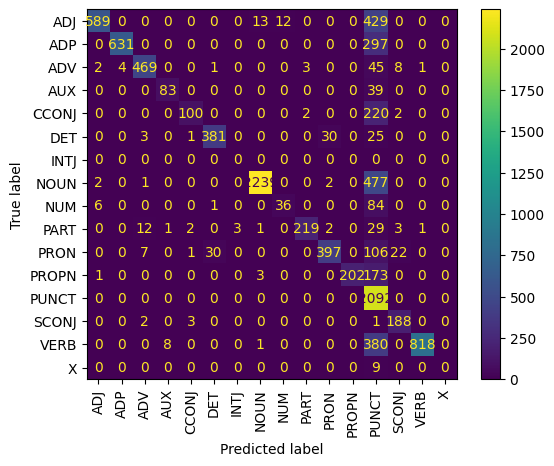

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(10,10))
ConfusionMatrixDisplay.from_predictions(
    test_df["upos"], pred1,
    xticks_rotation=90
)
plt.show()

<Figure size 1000x1000 with 0 Axes>

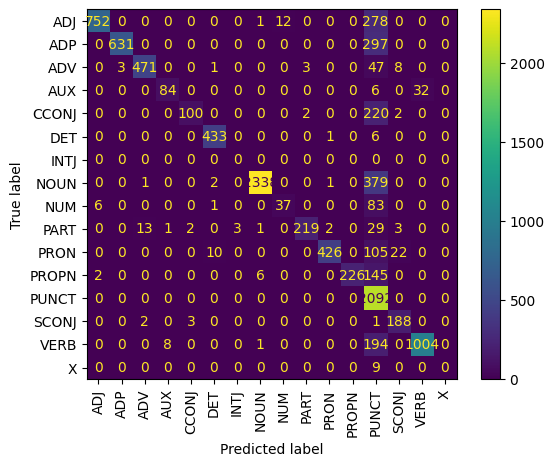

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(10,10))
ConfusionMatrixDisplay.from_predictions(
    test_df["upos"], pred2,
    xticks_rotation=90
)
plt.show()

In [ ]:
import numpy as np

vectorizer = pipe2.named_steps["tfidf"]
clf = pipe2.named_steps["clf"]

feature_names = np.array(vectorizer.get_feature_names_out())
classes = clf.classes_

for i, cls in enumerate(classes):
    top10 = np.argsort(clf.coef_[i])[-10:]
    print(f"\nTop features for {cls}:")
    print(feature_names[top10])


Top features for ADJ:
['відповідний' 'національний' 'шановний' 'перший' 'український'
 'державний' 'російський' 'верховний' 'політичний' 'народний']

Top features for ADP:
['по' 'із' 'на на' 'щодо' 'від' 'на' 'за' 'для' 'про' 'до']

Top features for ADV:
['потрібно' 'тут' 'також' 'дуже' 'ще' 'вже' 'треба' 'тому' 'зараз'
 'сьогодні']

Top features for AUX:
['будуть бути' 'були' 'були бути' 'буде' 'буде бути' 'будемо'
 'будемо бути' 'би би' 'би' 'бути']

Top features for CCONJ:
['однак' 'тобто' 'або або' 'проте' 'але але' 'чи' 'та та' 'або' 'але' 'та']

Top features for DET:
['ваш' 'кожний' 'інший' 'весь' 'свій' 'такий' 'той' 'який' 'наш' 'цей']

Top features for INTJ:
['ну' 'гаразд' 'спасибі спасибі' 'ні ні' 'да да' 'так так' 'ні' 'спасибі'
 'да' 'так']

Top features for NOUN:
['людина' 'проект' 'пропозиція' 'рада' 'рішення' 'фракція' 'рік' 'питання'
 'закон' 'депутат']

Top features for NUM:
['100' '17' '10' 'ять' '14' '15' '20' 'три' 'два' 'один']

Top features for PART:
['же' 'прост

In [ ]:
errors = test_df.copy()
errors["pred"] = pred2

errors = errors[errors["upos"] != errors["pred"]]

print("Кількість помилок:", len(errors))

errors[["token","lemma","upos","pred"]].head(10)

Кількість помилок: 1954


,token,lemma,upos,pred
2,116,116,NUM,PUNCT
7,І,і,CCONJ,PUNCT
10,41-а,41-й,ADJ,PUNCT
15,секундочку,секундочка,NOUN,PUNCT
17,41-а,41-й,ADJ,PUNCT
21,Чорний,Чорний,PROPN,ADJ
29,я,я,PRON,PUNCT
39,і,і,CCONJ,PUNCT
43,поправок,поправка,NOUN,PUNCT
46,в,в,ADP,PUNCT


In [ ]:
errors.head(20).to_json("error_cases_lab6.jsonl", orient="records", lines=True)

In [ ]:
# Клітинка 2: Imports
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, precision_recall_curve, auc)

import warnings
warnings.filterwarnings('ignore')

In [ ]:

train_df = pd.read_csv("train.csv")
val_df   = pd.read_csv("validation.csv")
test_df  = pd.read_csv("test.csv")

print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Test shape:", test_df.shape)

# Швидкий розподіл класів
print("Train class distribution:\n", train_df['upos'].value_counts(normalize=True))

Train shape: (87369, 8)
Val shape: (10842, 8)
Test shape: (10955, 8)
Train class distribution:
 upos
NOUN     0.245453
PUNCT    0.173769
VERB     0.110062
ADJ      0.100848
ADP      0.083393
PRON     0.056370
ADV      0.051208
DET      0.039293
PROPN    0.037199
CCONJ    0.035173
PART     0.022857
SCONJ    0.022285
AUX      0.010496
NUM      0.010232
X        0.000847
INTJ     0.000515
Name: proportion, dtype: float64


In [ ]:
# Клітинка 5: Lab6 Baseline (LogReg + TF-IDF word(1,2) + token+lemma)
X_train = train_df['token'] + " " + train_df['lemma']
X_val = val_df['token'] + " " + val_df['lemma']
X_test = test_df['token'] + " " + test_df['lemma']

y_train = train_df['upos']
y_val = val_df['upos']
y_test = test_df['upos']

# TF-IDF
vectorizer_baseline = TfidfVectorizer(analyzer='word', ngram_range=(1,2), sublinear_tf=True)
X_train_vec = vectorizer_baseline.fit_transform(X_train)
X_val_vec = vectorizer_baseline.transform(X_val)
X_test_vec = vectorizer_baseline.transform(X_test)

# Logistic Regression
lr_baseline = LogisticRegression(max_iter=200)
lr_baseline.fit(X_train_vec, y_train)

# Predictions
y_val_pred = lr_baseline.predict(X_val_vec)
y_test_pred = lr_baseline.predict(X_test_vec)

# Metrics
print("Baseline Lab6 - Validation")
print("Accuracy:", accuracy_score(y_val, y_val_pred))
print("Macro-F1:", f1_score(y_val, y_val_pred, average='macro'))
print(classification_report(y_val, y_val_pred))

Baseline Lab6 - Validation
Accuracy: 0.8121195351411179
Macro-F1: 0.7082044269051749
              precision    recall  f1-score   support

         ADJ       0.99      0.70      0.82      1062
         ADP       0.99      0.68      0.81       929
         ADV       0.97      0.85      0.90       536
         AUX       0.94      0.74      0.82        99
       CCONJ       0.98      0.33      0.49       322
         DET       0.99      0.97      0.98       396
        INTJ       0.00      0.00      0.00         0
        NOUN       1.00      0.83      0.91      2647
         NUM       0.78      0.42      0.55       136
        PART       0.99      0.78      0.87       259
        PRON       0.98      0.79      0.88       521
       PROPN       1.00      0.61      0.76       455
       PUNCT       0.51      1.00      0.68      2034
       SCONJ       0.92      0.99      0.95       206
        VERB       0.98      0.84      0.90      1202
           X       0.00      0.00      0.00       

In [ ]:
# Клітинка 6: Linear SVM Word baseline
vectorizer_word = TfidfVectorizer(analyzer='word', ngram_range=(1,2), sublinear_tf=True)
X_train_vec = vectorizer_word.fit_transform(X_train)
X_val_vec = vectorizer_word.transform(X_val)
X_test_vec = vectorizer_word.transform(X_test)

svm_word = LinearSVC(C=1.0)
svm_word.fit(X_train_vec, y_train)

y_val_pred_svm_word = svm_word.predict(X_val_vec)
y_test_pred_svm_word = svm_word.predict(X_test_vec)

print("LinearSVC Word - Validation")
print("Accuracy:", accuracy_score(y_val, y_val_pred_svm_word))
print("Macro-F1:", f1_score(y_val, y_val_pred_svm_word, average='macro'))

LinearSVC Word - Validation
Accuracy: 0.8558384061981185
Macro-F1: 0.7447160353144606


In [ ]:
# Клітинка 7: Linear SVM Word + Char ngrams
vectorizer_char = TfidfVectorizer(analyzer='char', ngram_range=(3,5), sublinear_tf=True)
X_train_char_vec = vectorizer_char.fit_transform(X_train)
X_val_char_vec = vectorizer_char.transform(X_val)
X_test_char_vec = vectorizer_char.transform(X_test)

svm_char = LinearSVC(C=1.0)
svm_char.fit(X_train_char_vec, y_train)

y_val_pred_svm_char = svm_char.predict(X_val_char_vec)
y_test_pred_svm_char = svm_char.predict(X_test_char_vec)

print("LinearSVC Word+Char - Validation")
print("Accuracy:", accuracy_score(y_val, y_val_pred_svm_char))
print("Macro-F1:", f1_score(y_val, y_val_pred_svm_char, average='macro'))

LinearSVC Word+Char - Validation
Accuracy: 0.9730676996864047
Macro-F1: 0.8349481256251869


In [ ]:
# Клітинка 8: LinearSVC + class_weight='balanced'
svm_char_balanced = LinearSVC(C=1.0, class_weight='balanced')
svm_char_balanced.fit(X_train_char_vec, y_train)

y_val_pred_bal = svm_char_balanced.predict(X_val_char_vec)
print("LinearSVC Word+Char + class_weight='balanced' - Validation")
print("Accuracy:", accuracy_score(y_val, y_val_pred_bal))
print("Macro-F1:", f1_score(y_val, y_val_pred_bal, average='macro'))

LinearSVC Word+Char + class_weight='balanced' - Validation
Accuracy: 0.9712230215827338
Macro-F1: 0.83639466699663


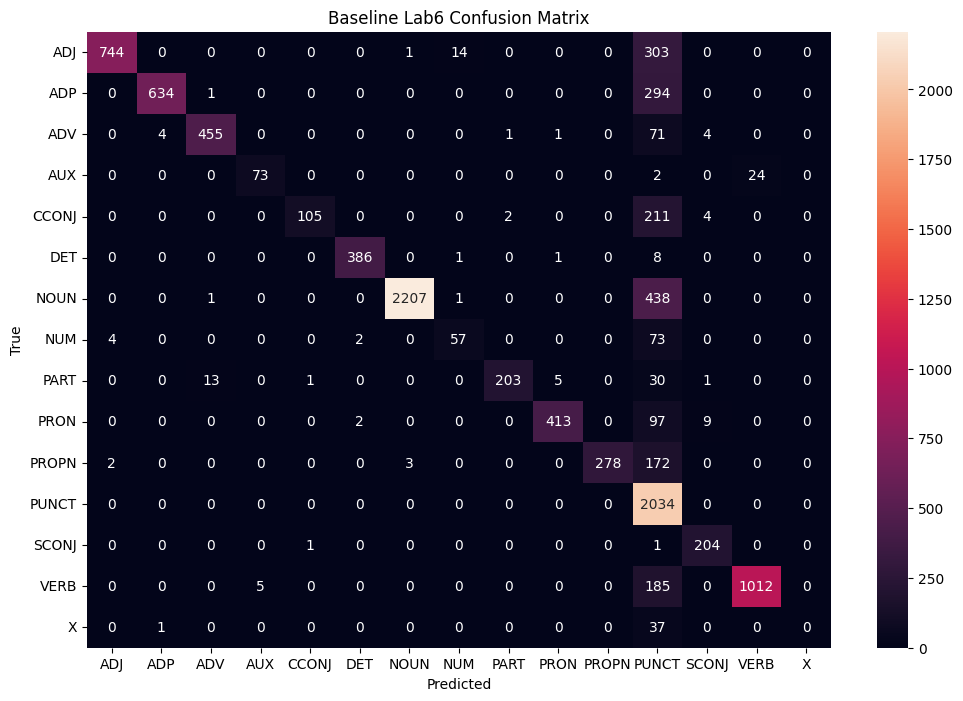

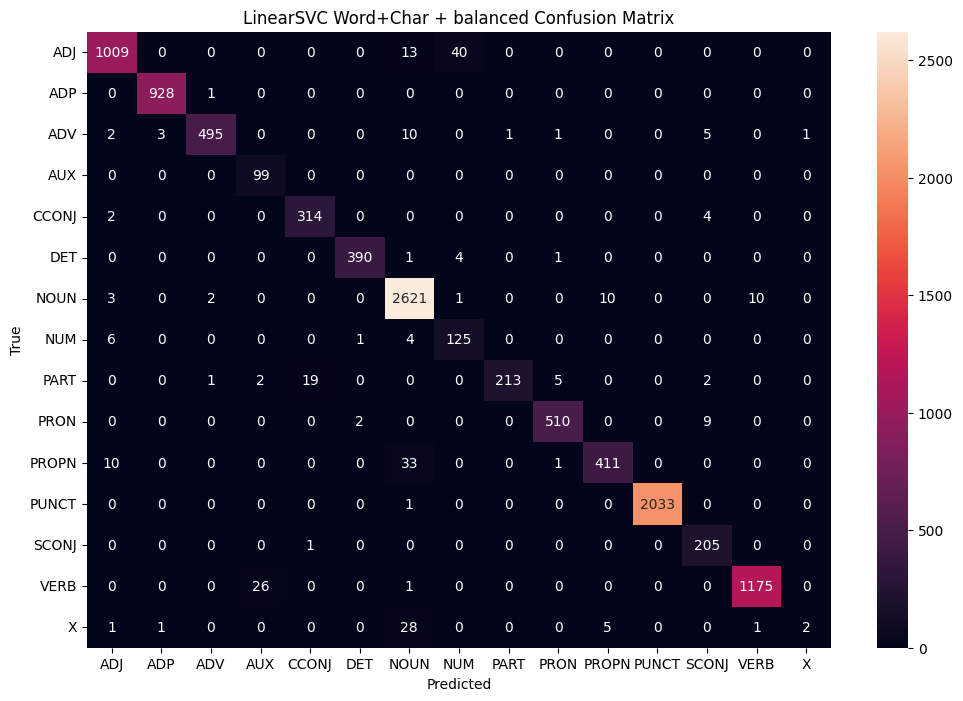

In [ ]:
# Клітинка 9: Confusion matrix for Lab6 vs best SVM
def plot_conf_matrix(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred, labels=np.unique(y_true))
    plt.figure(figsize=(12,8))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=np.unique(y_true), yticklabels=np.unique(y_true))
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.show()

# Baseline Lab6
plot_conf_matrix(y_val, y_val_pred, "Baseline Lab6 Confusion Matrix")

# Best SVM (Word+Char+balanced)
plot_conf_matrix(y_val, y_val_pred_bal, "LinearSVC Word+Char + balanced Confusion Matrix")

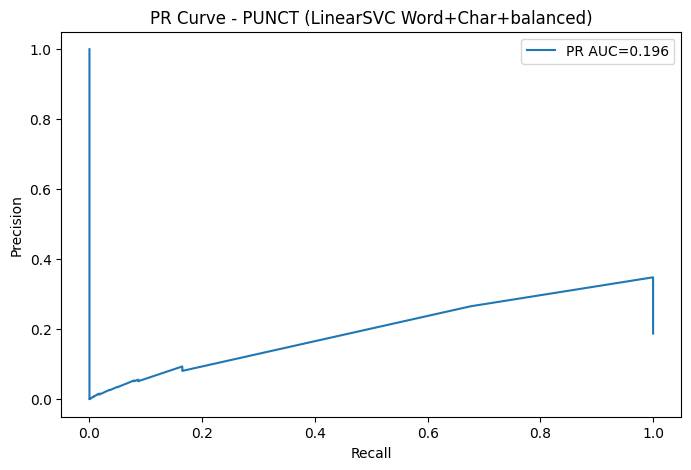

Chosen threshold for PUNCT: -1.0001195605494253


In [ ]:
# Клітинка 10: PR-curve for PUNCT
from sklearn.preprocessing import label_binarize

classes = y_train.unique()
y_train_bin = label_binarize(y_train, classes=classes)
y_val_bin = label_binarize(y_val, classes=classes)

punct_idx = list(classes).index('PUNCT')

# Decision function scores
scores_val = svm_char_balanced.decision_function(X_val_char_vec)
punct_scores = scores_val[:, punct_idx]
punct_true = y_val_bin[:, punct_idx]

precision, recall, thresholds = precision_recall_curve(punct_true, punct_scores)
auc_pr = auc(recall, precision)

plt.figure(figsize=(8,5))
plt.plot(recall, precision, label=f'PR AUC={auc_pr:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('PR Curve - PUNCT (LinearSVC Word+Char+balanced)')
plt.legend()
plt.show()

# Example: choose threshold that balances precision/recall
thresh_idx = np.argmax(precision + recall)  # simple balance
best_threshold = thresholds[thresh_idx]
print("Chosen threshold for PUNCT:", best_threshold)

In [ ]:
# Клітинка 11: Error analysis
val_df['pred'] = y_val_pred_bal
errors = val_df[val_df['upos'] != val_df['pred']]
errors_sample = errors.sample(10, random_state=42)

for idx, row in errors_sample.iterrows():
    print(f"Sent {row['sent_id']} | Token: {row['token']} | Gold: {row['upos']} | Pred: {row['pred']}")

Sent ParlaMint-UA_2022-01-25-m0.u160.p1.lang1.s2 | Token: 3 | Gold: ADJ | Pred: NUM
Sent ParlaMint-UA_2022-01-25-m0.u92.p2.lang1.s4 | Token: так | Gold: ADV | Pred: INTJ
Sent ParlaMint-UA_2022-01-25-m0.u110.p2.lang1.s4 | Token: Туреччини | Gold: PROPN | Pred: NOUN
Sent ParlaMint-UA_2022-01-25-m0.u112.p1.lang1.s2 | Token: 6199 | Gold: NUM | Pred: ADJ
Sent ParlaMint-UA_2022-01-25-m0.u99.p12.lang1.s2 | Token: Будемо | Gold: VERB | Pred: AUX
Sent ParlaMint-UA_2022-01-25-m0.u115.p1.lang1.s1 | Token: головуючий | Gold: ADJ | Pred: NOUN
Sent ParlaMint-UA_2022-01-25-m0.u116.p1.lang1.s1 | Token: Забродському | Gold: PROPN | Pred: ADJ
Sent ParlaMint-UA_2022-01-25-m0.u143.p2.lang1.s7 | Token: книгорозповсюджувачам | Gold: NOUN | Pred: PROPN
Sent ParlaMint-UA_2022-01-25-m0.u172.p4.lang1.s5 | Token: position | Gold: X | Pred: NOUN
Sent ParlaMint-UA_2022-01-25-m0.u106.p2.lang1.s6 | Token: і | Gold: PART | Pred: CCONJ


Validation Metrics Comparison


,Model,Features,Class_weight,Accuracy,Macro-F1
0,LogReg Baseline (Lab6),"word(1,2)",no,0.812120,0.708204
1,LinearSVC Word,"word(1,2)",no,0.855838,0.744716
2,LinearSVC Word+Char,"word+char(3,5)",balanced,0.971223,0.836395


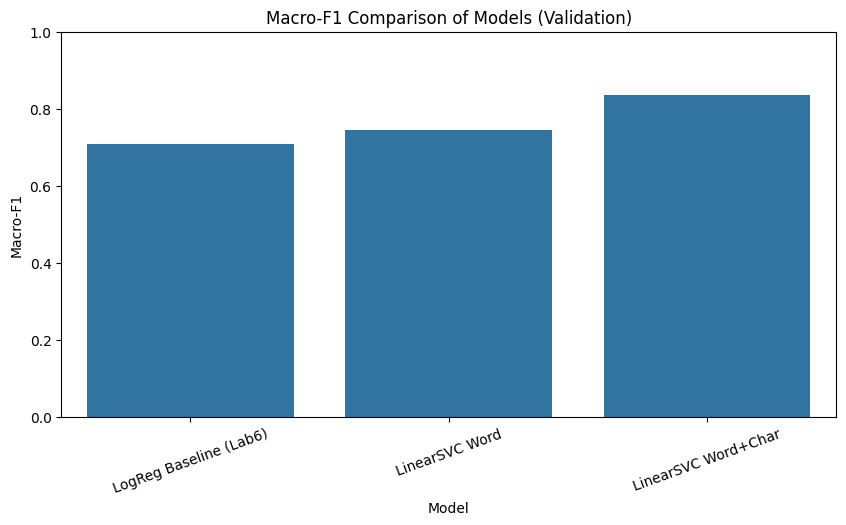

In [ ]:
# Клітинка 13: Compare all models in a table
results = []

# Lab6 baseline
results.append({
    "Model": "LogReg Baseline (Lab6)",
    "Features": "word(1,2)",
    "Class_weight": "no",
    "Accuracy": accuracy_score(y_val, y_val_pred),
    "Macro-F1": f1_score(y_val, y_val_pred, average='macro')
})

# LinearSVC word
results.append({
    "Model": "LinearSVC Word",
    "Features": "word(1,2)",
    "Class_weight": "no",
    "Accuracy": accuracy_score(y_val, y_val_pred_svm_word),
    "Macro-F1": f1_score(y_val, y_val_pred_svm_word, average='macro')
})

# LinearSVC word + char + balanced
results.append({
    "Model": "LinearSVC Word+Char",
    "Features": "word+char(3,5)",
    "Class_weight": "balanced",
    "Accuracy": accuracy_score(y_val, y_val_pred_bal),
    "Macro-F1": f1_score(y_val, y_val_pred_bal, average='macro')
})

results_df = pd.DataFrame(results)
results_df = results_df[["Model","Features","Class_weight","Accuracy","Macro-F1"]]

# Display nicely
print("Validation Metrics Comparison")
display(results_df)

# Optional: barplot for visual comparison
plt.figure(figsize=(10,5))
sns.barplot(x="Model", y="Macro-F1", data=results_df)
plt.title("Macro-F1 Comparison of Models (Validation)")
plt.ylabel("Macro-F1")
plt.xticks(rotation=20)
plt.ylim(0,1)
plt.show()